# EC Sales Analysis

## 目的
売上データを分析し、傾向を把握する

In [ ]:
pip install pandas matplotlib

Defaulting to user installation because normal site-packages is not writeable
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --------------- ------------------------ 3.1/8.1 MB 16.5 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.1 MB 17.5 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 15.4 MB/s  0:00:00
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 16.0 MB/s  0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ----------------- ---------------------- 3.1/7.1 MB 15.3 MB/s eta 0:00:01
   -------------------------------------- - 6.8/7.1 MB 16.8 MB/s eta 0:00:01
   

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\miku_\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [71]:
import pandas as pd

# =========================
# ① データ読み込み
# =========================
df = pd.read_csv(
    "../data/raw_expenses.csv",
    encoding="utf-8-sig",
    usecols=[1,2,3,4,5,6,7],  # B〜H列
    header=None
)

df.columns = [
    "date_raw",
    "shop",          # ← 後で削除
    "amount_raw",
    "amount",
    "month",
    "category_main",
    "category_sub"
]

# =========================
# ② 日付整形
# =========================
df["date"] = df["date_raw"].str.extract(r"(\d+年\d+月\d+日)")
df["date"] = pd.to_datetime(df["date"], format="%Y年%m月%d日")

# =========================
# ③ 数値整形
# =========================
df["amount"] = pd.to_numeric(df["amount"], errors="coerce")

# =========================
# ④ 月列再生成
# =========================
df["month"] = df["date"].dt.to_period("M")

# =========================
# ⑤ 店舗名削除（重要）
# =========================
df_clean = df.drop(columns=["shop", "date_raw", "amount_raw"])

# =========================
# ⑥ 保存
# =========================
df_clean.to_csv("../data/expenses_clean.csv", index=False, encoding="utf-8-sig")

df_clean.head()

,amount,month,category_main,category_sub,date
0,1830.0,2025-09,生活費,日用品,2025-09-09
1,688.0,2025-09,生活費,食費,2025-09-09
2,1100.0,2025-09,生活費,日用品,2025-09-08
3,54.0,2025-09,生活費,日用品,2025-09-07
4,217.0,2025-09,生活費,日用品,2025-09-07


# 個人情報配慮について

本データには店舗名が含まれており、
居住エリアや行動パターンが推測可能であるため削除し
カテゴリ単位での分析に統一した。

In [80]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/expenses_clean.csv", encoding="utf-8-sig")

df["date"] = pd.to_datetime(df["date"])#データ型
df["month"] = df["date"].dt.to_period("M")
df[["date", "amount", "category_sub"]].isnull().sum()#欠損確認

date            570
amount          570
category_sub    570
dtype: int64

In [81]:
category = df.groupby("category_sub")["amount"].sum().sort_values(ascending=False)
category

category_sub
食費      215739.0
旅行      177543.0
光熱費      90023.0
外食       87172.0
特別       57048.0
日用品      41433.0
要確認      18870.0
水道       13068.0
サブスク      1780.0
Name: amount, dtype: float64

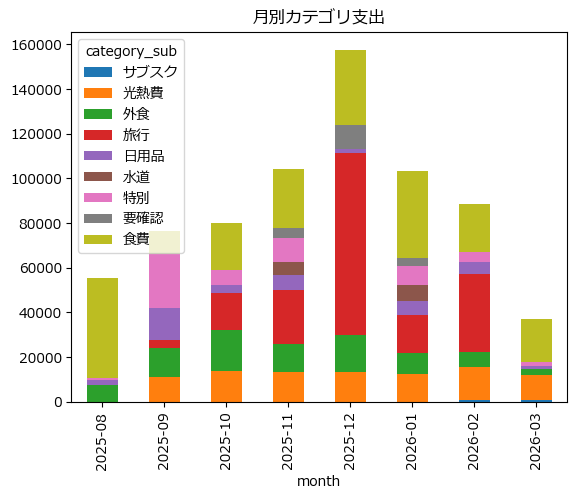

In [78]:
pivot = df.pivot_table(
    index="month",
    columns="category_sub",
    values="amount",
    aggfunc="sum"
)

pivot.plot(kind="bar", stacked=True)
plt.title("月別カテゴリ支出")
plt.show()

In [ ]:
# 異常検出　Zスコア計算
df["z_score"] = (
    (df["amount"] - df["amount"].mean()) / df["amount"].std()
)

# 閾値2以上を異常とする
outliers = df[df["z_score"].abs() > 2]

outliers.sort_values("amount", ascending=False).head(10)

,amount,month,category_main,category_sub,date,z_score
177,60000.0,2025-12,一時費,旅行,2025-12-20,11.320228
204,29192.0,2026-02,一時費,旅行,2026-02-01,5.258582
59,23400.0,2025-09,一時費,特別,2025-09-17,4.118974
9,23235.0,2025-08,生活費,食費,2025-08-31,4.086509
219,16680.0,2026-01,一時費,食費,2026-01-26,2.796776
32,16500.0,2025-10,一時費,旅行,2025-10-10,2.761360
196,14733.0,2026-02,固定費,光熱費,2026-02-05,2.413693
34,13762.0,2025-10,固定費,光熱費,2025-10-06,2.222644
108,13486.0,2025-12,固定費,光熱費,2025-12-04,2.168339
71,13190.0,2025-11,固定費,光熱費,2025-11-07,2.110099


本分析では、家計データをもとに支出構造の可視化と異常検出を行った。

・カテゴリ別集計により支出の集中領域を把握
・月別推移により時系列での変化を可視化
・Zスコアにより異常支出を定量的に検出

これにより、支出の傾向把握および改善余地の特定が可能となる。